# Movie Dataset - Modeling Readiness and Visualization

## Key decisions before modeling
1. Keep data in a **DataFrame** for cleaning and feature engineering.
2. Convert to **NumPy arrays/tensors** only right before model training.
3. Encode categorical/multi-label features (`Genre`).
4. Scale numeric features (`Year`) for distance-based models and dimensionality reduction.
5. Use PCA/t-SNE as visualization tools, not as final proof of separability.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler, Normalizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set_theme(style="whitegrid", context="notebook")

csv_path = "Final.Database.csv"
df = pd.read_csv(csv_path, skipinitialspace=True)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (643, 4)
Columns: ['Movie', 'Year', 'TMDB_Link', 'Genre']


,Movie,Year,TMDB_Link,Genre
0,3 Idiots,2009.0,https://www.themoviedb.org/movie/20453,"Drama, Comedy"
1,Nanban,2012.0,https://www.themoviedb.org/movie/69537,"Comedy, Drama"
2,3 Idiotas,2017.0,https://www.themoviedb.org/movie/346034,"Family, Comedy"
3,Pyar Jhukta Nahin,1985.0,https://www.themoviedb.org/movie/441793,NaN
4,Nee Bareda Kadambari,1985.0,https://www.themoviedb.org/movie/1385360,"Drama, Romance"


In [2]:
print("Missing values:")
print(df.isna().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

# Basic cleanup
df_clean = df.copy()
df_clean["Movie"] = df_clean["Movie"].astype(str).str.strip()
df_clean["Genre"] = df_clean["Genre"].fillna("Unknown").astype(str)
df_clean["Year"] = pd.to_numeric(df_clean["Year"], errors="coerce")
df_clean["Year"] = df_clean["Year"].fillna(df_clean["Year"].median())

print("\nYear summary:")
print(df_clean["Year"].describe())

Missing values:
Movie         0
Year          0
TMDB_Link     0
Genre        10
dtype: int64

Duplicate rows: 0

Year summary:
count     643.000000
mean     1994.160187
std        18.162751
min      1932.000000
25%      1980.000000
50%      1999.000000
75%      2008.000000
max      2025.000000
Name: Year, dtype: float64


In [ ]:
# multi-label encoding for Genre
genre_lists = (
    df_clean["Genre"]
    .str.split(",")
    .apply(lambda lst: [g.strip() for g in lst if g.strip()])
)

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(genre_lists)
genre_df = pd.DataFrame(genre_matrix, columns=[f"genre_{g}" for g in mlb.classes_])

X_raw = pd.concat([df_clean[["Year"]].reset_index(drop=True), genre_df.reset_index(drop=True)], axis=1)

# Standard scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Optional L2 normalization (useful for cosine/distance comparisons)
normalizer = Normalizer()
X_norm = normalizer.fit_transform(X_scaled)

print("Feature table shape:", X_raw.shape)
print("Scaled array shape:", X_scaled.shape)
print("Normalized array shape:", X_norm.shape)
X_raw.head()

Feature table shape: (643, 21)
Scaled array shape: (643, 21)
Normalized array shape: (643, 21)


,Year,genre_Action,genre_Adventure,genre_Animation,genre_Comedy,genre_Crime,genre_Documentary,genre_Drama,genre_Family,genre_Fantasy,...,genre_Horror,genre_Music,genre_Mystery,genre_Romance,genre_Science Fiction,genre_TV Movie,genre_Thriller,genre_Unknown,genre_War,genre_Western
0,2009.0,0,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2012.0,0,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2017.0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,1985.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,1985.0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,0,0


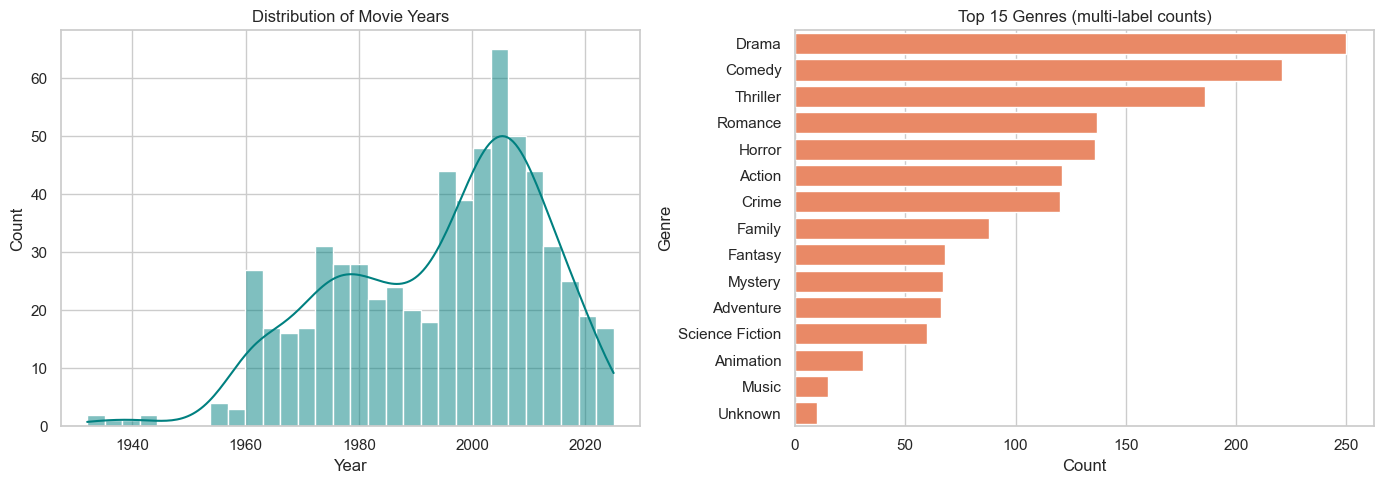

In [4]:
# Feature distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean["Year"], bins=30, kde=True, ax=axes[0], color="teal")
axes[0].set_title("Distribution of Movie Years")

genre_counts = genre_df.sum().sort_values(ascending=False).head(15)
sns.barplot(x=genre_counts.values, y=genre_counts.index.str.replace("genre_", ""), ax=axes[1], color="coral")
axes[1].set_title("Top 15 Genres (multi-label counts)")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Genre")

plt.tight_layout()
plt.show()

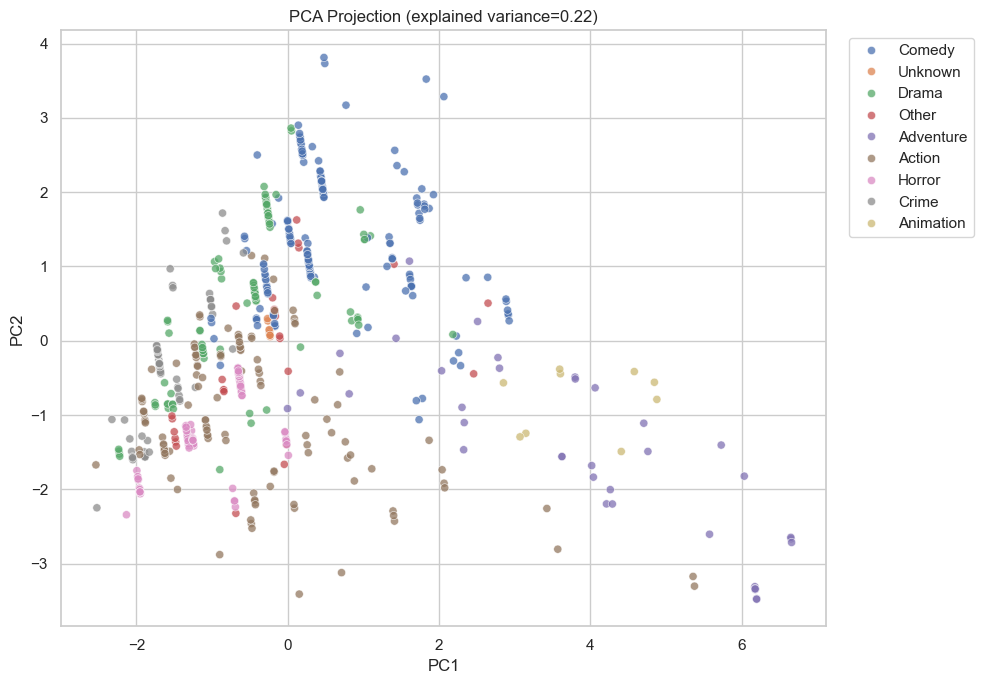

In [5]:
# PCA visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Dominant genre for coloring points
dominant_genre_idx = genre_df.values.argmax(axis=1)
dominant_genre = np.array(genre_df.columns)[dominant_genre_idx]
dominant_genre = pd.Series(dominant_genre).str.replace("genre_", "", regex=False)

plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "DominantGenre": dominant_genre
})

top_genres = plot_df["DominantGenre"].value_counts().head(8).index
plot_df["GenreGroup"] = np.where(plot_df["DominantGenre"].isin(top_genres), plot_df["DominantGenre"], "Other")

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="GenreGroup", alpha=0.75, s=35)
plt.title(f"PCA Projection (explained variance={pca.explained_variance_ratio_.sum():.2f})")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

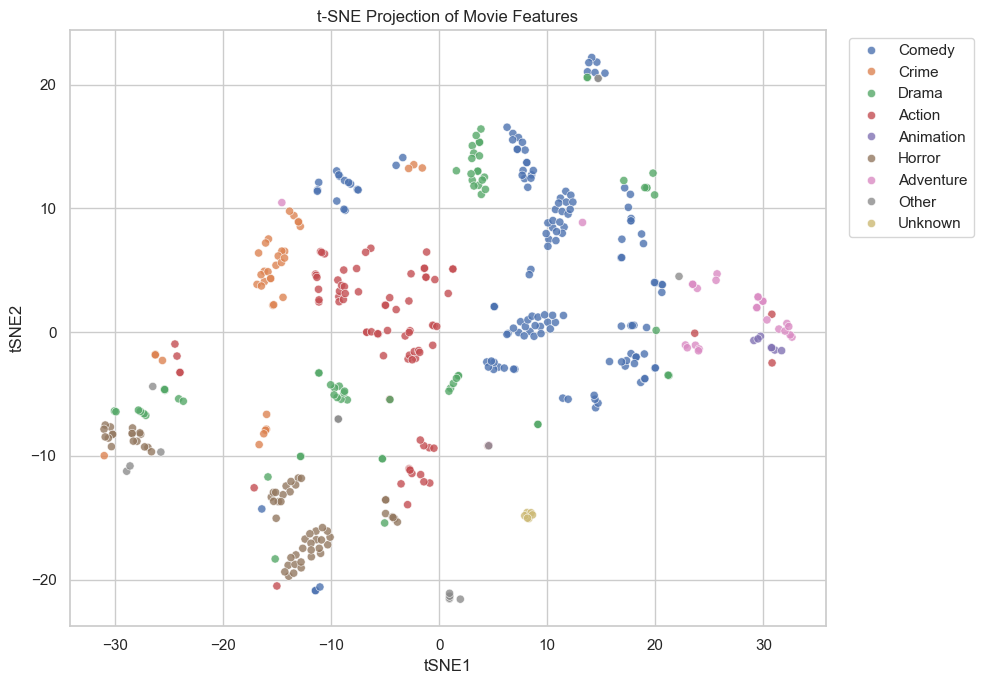

In [6]:
# t-SNE visualization (sample for speed and readability)
sample_n = min(450, len(X_scaled))
sample_idx = np.random.RandomState(42).choice(len(X_scaled), size=sample_n, replace=False)
X_sample = X_scaled[sample_idx]
genre_sample = plot_df.iloc[sample_idx]["GenreGroup"].reset_index(drop=True)

tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=42)
X_tsne = tsne.fit_transform(X_sample)

tsne_df = pd.DataFrame({
    "tSNE1": X_tsne[:, 0],
    "tSNE2": X_tsne[:, 1],
    "GenreGroup": genre_sample
})

plt.figure(figsize=(10, 7))
sns.scatterplot(data=tsne_df, x="tSNE1", y="tSNE2", hue="GenreGroup", alpha=0.8, s=35)
plt.title("t-SNE Projection of Movie Features")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Answers (aligned with course repos)
- **DataFrame or Tensor?** Start with DataFrame (WK05/WK06). Convert to arrays/tensors at training time (Homework11/Homework12).
- **Encoding?** Yes. `Genre` is multi-label text and must be encoded (WK05, Homework07/08).
- **Scaling/Normalization?** Yes for distance-based methods and PCA/t-SNE (WK08/WK09).
- **Plot distributions?** Yes, essential to inspect Year skew, sparse genres, imbalance.
- **PCA/t-SNE useful?** Yes for exploratory shape visualization, but validate with proper models/metrics afterwards.
- **Media characteristics?** Use poster color histograms and brightness distributions in the second notebook.

## Milestone Final Part: Modeling, Tuning, and Evaluation

- What model type is used?
- Which algorithms are tested?
- How do tuning and preprocessing choices affect results?
- How do we evaluate mathematically and visually?

### Modeling choice
We use **multi-class classification** to predict the movie's primary genre from metadata-derived features (`Movie` title text + `Year`).

In [13]:
# Build supervised dataset: predict primary genre
supervised_df = df_clean.copy()
supervised_df["PrimaryGenre"] = (
    supervised_df["Genre"]
    .astype(str)
    .str.split(",")
    .str[0]
    .str.strip()
)

# Keep the most frequent genres to avoid extreme class sparsity
TOP_K = 8
top_labels = supervised_df["PrimaryGenre"].value_counts().head(TOP_K).index
supervised_df = supervised_df[supervised_df["PrimaryGenre"].isin(top_labels)].copy()

X = supervised_df[["Movie", "Year"]].copy()
y = supervised_df["PrimaryGenre"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Rows used for supervised modeling:", len(supervised_df))
print("Classes:", sorted(y.unique()))
print("Train/Test:", X_train.shape, X_test.shape)

Rows used for supervised modeling: 549
Classes: ['Action', 'Adventure', 'Comedy', 'Crime', 'Drama', 'Family', 'Horror', 'Thriller']
Train/Test: (411, 2) (138, 2)


          Model  Accuracy   MacroF1
1     LinearSVC  0.260870  0.251330
0        LogReg  0.260870  0.241617
2  RandomForest  0.224638  0.196267


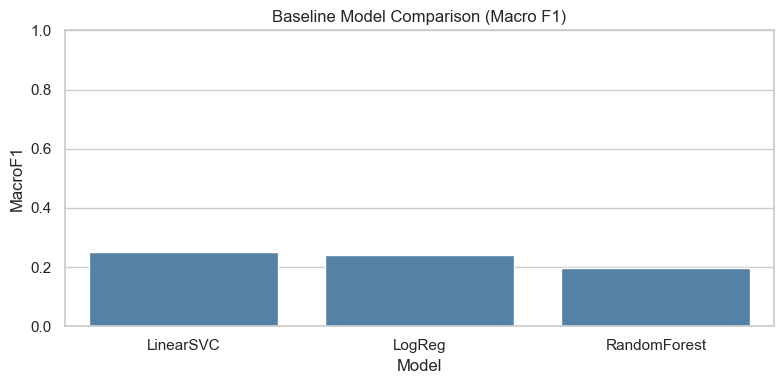

In [14]:
# Shared preprocessing: TF-IDF on title + scaling on year
preprocess = ColumnTransformer(
    transformers=[
        (
            "title_tfidf",
            TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=2, max_features=1200),
            "Movie"
        ),
        (
            "year_scale",
            StandardScaler(),
            ["Year"]
        )
    ],
    remainder="drop"
)

models = {
    "LogReg": LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42),
    "LinearSVC": LinearSVC(class_weight="balanced", random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=350, max_depth=None, random_state=42)
}

baseline_rows = []
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocess),
        ("model", model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, pred)
    f1m = f1_score(y_test, pred, average="macro")

    baseline_rows.append({
        "Model": name,
        "Accuracy": acc,
        "MacroF1": f1m
    })
    trained_pipelines[name] = pipe

baseline_results = pd.DataFrame(baseline_rows).sort_values("MacroF1", ascending=False)
print(baseline_results)

plt.figure(figsize=(8, 4))
sns.barplot(data=baseline_results, x="Model", y="MacroF1", color="steelblue")
plt.ylim(0, 1)
plt.title("Baseline Model Comparison (Macro F1)")
plt.tight_layout()
plt.show()

In [15]:
# Hyperparameter tuning on Logistic Regression pipeline
log_pipe = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42))
])

param_grid = {
    "prep__title_tfidf__ngram_range": [(1, 1), (1, 2)],
    "prep__title_tfidf__min_df": [1, 2, 3],
    "prep__title_tfidf__max_features": [600, 1200, 2000],
    "model__C": [0.3, 1.0, 3.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=log_pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Best params:", grid.best_params_)
print("Best CV MacroF1:", round(grid.best_score_, 4))
print("Test Accuracy:", round(accuracy_score(y_test, y_pred_best), 4))
print("Test MacroF1:", round(f1_score(y_test, y_pred_best, average="macro"), 4))

cv_results = pd.DataFrame(grid.cv_results_).sort_values("mean_test_score", ascending=False)
cv_results[[
    "mean_test_score",
    "param_prep__title_tfidf__ngram_range",
    "param_prep__title_tfidf__min_df",
    "param_prep__title_tfidf__max_features",
    "param_model__C"
]].head(10)

Best params: {'model__C': 1.0, 'prep__title_tfidf__max_features': 1200, 'prep__title_tfidf__min_df': 1, 'prep__title_tfidf__ngram_range': (1, 2)}
Best CV MacroF1: 0.3143
Test Accuracy: 0.4348
Test MacroF1: 0.394


,mean_test_score,param_prep__title_tfidf__ngram_range,param_prep__title_tfidf__min_df,param_prep__title_tfidf__max_features,param_model__C
31,0.314331,"(1, 2)",1,2000,1.0
25,0.314331,"(1, 2)",1,1200,1.0
49,0.303951,"(1, 2)",1,2000,3.0
43,0.303951,"(1, 2)",1,1200,3.0
48,0.303712,"(1, 1)",1,2000,3.0
42,0.303712,"(1, 1)",1,1200,3.0
36,0.303712,"(1, 1)",1,600,3.0
30,0.292817,"(1, 1)",1,2000,1.0
18,0.292817,"(1, 1)",1,600,1.0
24,0.292817,"(1, 1)",1,1200,1.0


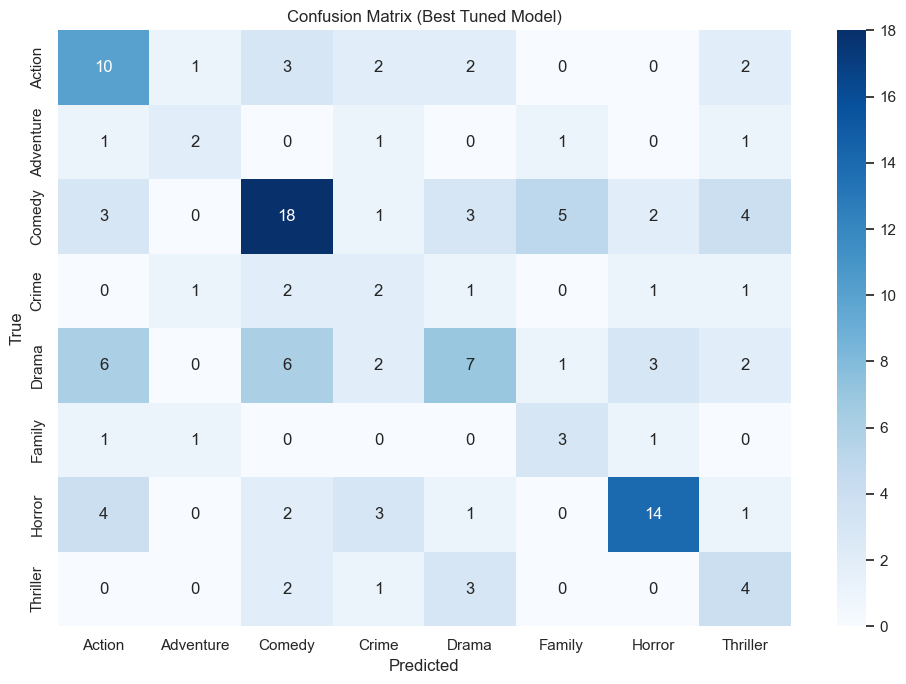

              precision    recall  f1-score   support

      Action      0.400     0.500     0.444        20
   Adventure      0.400     0.333     0.364         6
      Comedy      0.545     0.500     0.522        36
       Crime      0.167     0.250     0.200         8
       Drama      0.412     0.259     0.318        27
      Family      0.300     0.500     0.375         6
      Horror      0.667     0.560     0.609        25
    Thriller      0.267     0.400     0.320        10

    accuracy                          0.435       138
   macro avg      0.395     0.413     0.394       138
weighted avg      0.461     0.435     0.440       138



In [16]:
# Visual + mathematical evaluation
labels_sorted = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred_best, labels=labels_sorted)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_sorted, yticklabels=labels_sorted)
plt.title("Confusion Matrix (Best Tuned Model)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_best, digits=3))

   TrainFraction  TrainRows   MacroF1  Accuracy
0            0.2         82  0.137988  0.210145
1            0.4        164  0.240881  0.311594
2            0.6        246  0.354493  0.355072
3            0.8        328  0.385071  0.427536
4            1.0        411  0.393962  0.434783


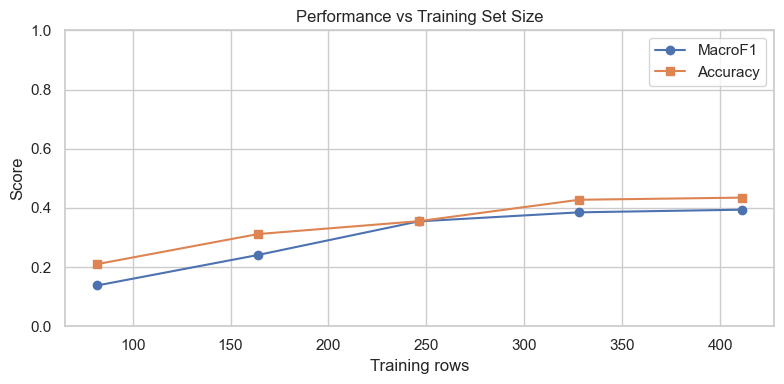

In [17]:
# Data-size sensitivity: fewer samples vs more data trend
fractions = [0.2, 0.4, 0.6, 0.8, 1.0]
rows = []

for frac in fractions:
    n = max(40, int(len(X_train) * frac))
    idx = X_train.sample(n=n, random_state=42).index

    X_sub = X_train.loc[idx]
    y_sub = y_train.loc[idx]

    model_sub = grid.best_estimator_
    model_sub.fit(X_sub, y_sub)
    pred_sub = model_sub.predict(X_test)

    rows.append({
        "TrainFraction": frac,
        "TrainRows": n,
        "MacroF1": f1_score(y_test, pred_sub, average="macro"),
        "Accuracy": accuracy_score(y_test, pred_sub)
    })

scale_df = pd.DataFrame(rows)
print(scale_df)

plt.figure(figsize=(8, 4))
plt.plot(scale_df["TrainRows"], scale_df["MacroF1"], marker="o", label="MacroF1")
plt.plot(scale_df["TrainRows"], scale_df["Accuracy"], marker="s", label="Accuracy")
plt.ylim(0, 1)
plt.title("Performance vs Training Set Size")
plt.xlabel("Training rows")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()